# Electricity Demand Forecasting

Este notebook tiene como objetivo resolver un ejercicio de series temporales utilizando un subconjunto del dataset `electricity_demand`. Se entrenan y comparan distintos modelos de regresión para predecir la demanda eléctrica de un día completo (24 horas), utilizando como entrada las 24 horas previas.

# Importación de librerías

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# xgboost
import xgboost as xgb

# Guardar modelo
from joblib import dump
import joblib

# Estilo para visualizaciones
sns.set(style="whitegrid")

# Explicabilidad
import shap

/home/andresmtr/miniconda3/envs/PruebaBRM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carga del dataset

In [2]:
# Se carga el conjunto de datos `rajistics/electricity_demand` desde Hugging Face. Este contiene valores de demanda eléctrica por hora.

dataset = load_dataset("rajistics/electricity_demand", split="train")
df = pd.DataFrame(dataset)
print("Columnas disponibles:", df.columns)
print("Primeras filas del dataset:")
df.head()


Columnas disponibles: Index(['Demand', 'Temperature', '__index_level_0__'], dtype='object')
Primeras filas del dataset:


,Demand,Temperature,__index_level_0__
0,3.794,18.05,2014-01-01 00:00:00
1,3.418,17.20,2014-01-01 01:00:00
2,3.152,16.45,2014-01-01 02:00:00
3,3.026,16.65,2014-01-01 03:00:00
4,3.022,16.40,2014-01-01 04:00:00


In [3]:
# se verifica si existe datos cada 30 minutos, lo cual no se puede ver, ya que salen datos cada hora

df['__index_level_0__'].unique()

<DatetimeArray>
['2014-01-01 00:00:00', '2014-01-01 01:00:00', '2014-01-01 02:00:00',
 '2014-01-01 03:00:00', '2014-01-01 04:00:00', '2014-01-01 05:00:00',
 '2014-01-01 06:00:00', '2014-01-01 07:00:00', '2014-01-01 08:00:00',
 '2014-01-01 09:00:00',
 ...
 '2014-02-25 14:00:00', '2014-02-25 15:00:00', '2014-02-25 16:00:00',
 '2014-02-25 17:00:00', '2014-02-25 18:00:00', '2014-02-25 19:00:00',
 '2014-02-25 20:00:00', '2014-02-25 21:00:00', '2014-02-25 22:00:00',
 '2014-02-25 23:00:00']
Length: 1344, dtype: datetime64[ns]

Entrenar un modelo que use un día completo (24 datos por hora) para predecir el día siguiente (otros 24 datos por hora)."

In [4]:
df = pd.DataFrame(dataset)
print("Primeras filas del dataset:")
df.head(30)


Primeras filas del dataset:


,Demand,Temperature,__index_level_0__
0,3.794,18.05,2014-01-01 00:00:00
1,3.418,17.20,2014-01-01 01:00:00
2,3.152,16.45,2014-01-01 02:00:00
3,3.026,16.65,2014-01-01 03:00:00
4,3.022,16.40,2014-01-01 04:00:00
5,3.055,17.95,2014-01-01 05:00:00
6,3.180,19.70,2014-01-01 06:00:00
7,3.276,20.60,2014-01-01 07:00:00
8,3.467,22.35,2014-01-01 08:00:00
9,3.620,23.70,2014-01-01 09:00:00


In [5]:
df.columns

Index(['Demand', 'Temperature', '__index_level_0__'], dtype='object')

In [6]:
len(df)

1344

In [7]:
df.tail()

,Demand,Temperature,__index_level_0__
1339,4.968,20.10,2014-02-25 19:00:00
1340,4.742,19.90,2014-02-25 20:00:00
1341,4.304,19.30,2014-02-25 21:00:00
1342,4.105,19.05,2014-02-25 22:00:00
1343,4.410,18.85,2014-02-25 23:00:00


# Preprocesamiento de los datos

In [8]:
# Preprocesamiento de la hora
df['__index_level_0__'] = pd.to_datetime(df['__index_level_0__'])
df = df.sort_values('__index_level_0__')
df['date'] = df['__index_level_0__'].dt.date

In [9]:
df.head()

,Demand,Temperature,__index_level_0__,date
0,3.794,18.05,2014-01-01 00:00:00,2014-01-01
1,3.418,17.20,2014-01-01 01:00:00,2014-01-01
2,3.152,16.45,2014-01-01 02:00:00,2014-01-01
3,3.026,16.65,2014-01-01 03:00:00,2014-01-01
4,3.022,16.40,2014-01-01 04:00:00,2014-01-01


In [10]:
# Usar solo el 20% inicial del dataset dice el ejercicio, sin embargo con tan pocos datos el resultado no es el mejor, por eso, decidi usar el 80% de los datos totales

total_rows = len(df)
subset_rows = int(total_rows * 0.80)
df_subset = df.iloc[:subset_rows].reset_index(drop=True)

len(df_subset)

1075

In [11]:
# Crear pares de 24 horas para entrada y 24 para salida
values = df_subset['Demand'].values
window_size = 24
horizon = 24


In [12]:
X = []
y = []
for i in range(len(values) - window_size - horizon):
    X.append(values[i:i+window_size])
    y.append(values[i+window_size:i+window_size+horizon])

X = np.array(X)
y = np.array(y)


# Entrenamiento

In [13]:
# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Modelos a evaluar, se decide usar varios para despues indicar cual es el mejor
models = {
    "LinearRegressionH": LinearRegression(fit_intercept=True),
    
    "DecisionTreeRegressorH": DecisionTreeRegressor(
        max_depth=20, 
        min_samples_split=5, 
        min_samples_leaf=2, 
        max_features='sqrt',
        random_state=42
    ),
    
    "RandomForestRegressorH": RandomForestRegressor(
        n_estimators=500, 
        max_depth=30,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42
    ),
    
    "XGBRegressorH": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        tree_method="hist"  
    )
}

In [15]:
# Diccionario para almacenar resultados
results = {
    "Model": [],
    "MAE": [],
    "MSE": [],
    "RMSE": [],
    "R2": []
}



### Entrenando modelo: LinearRegressionH

MAE: 0.58, MSE: 0.63, RMSE: 0.79, R2: 0.70


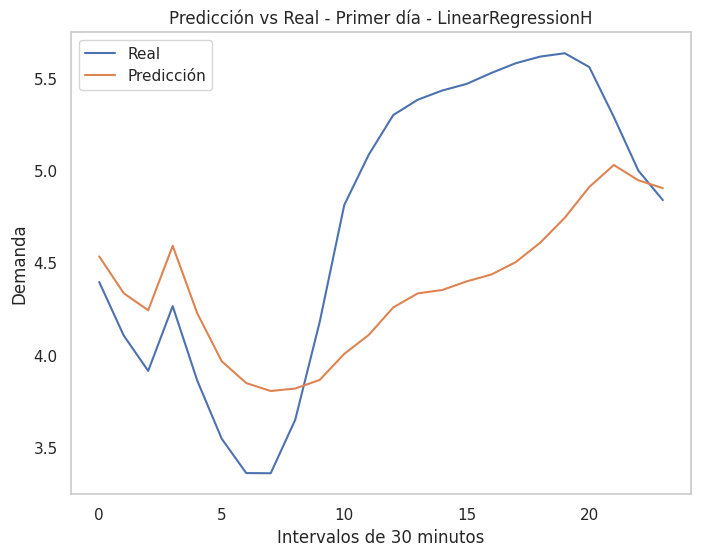

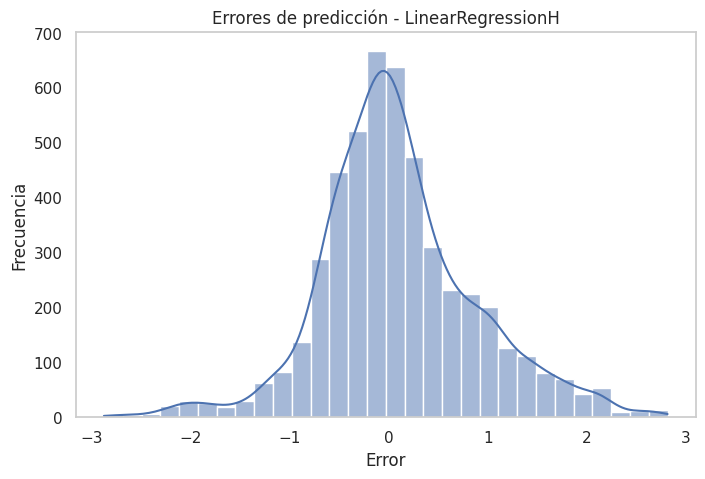


### Entrenando modelo: DecisionTreeRegressorH

MAE: 0.67, MSE: 1.06, RMSE: 1.03, R2: 0.50


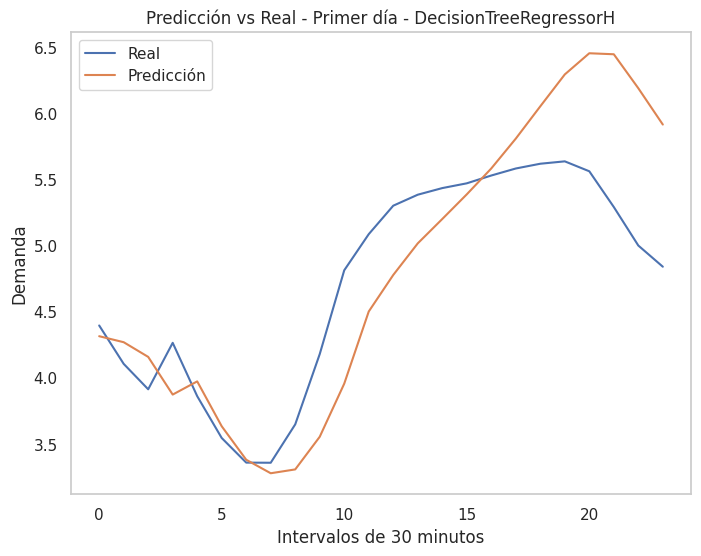

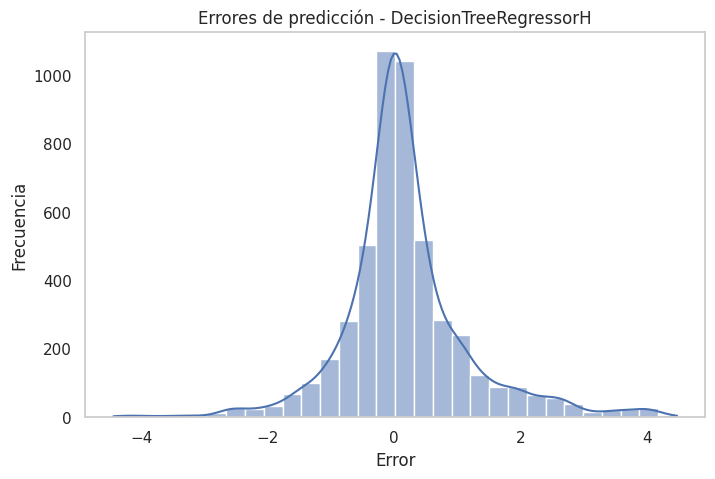


### Entrenando modelo: RandomForestRegressorH

MAE: 0.55, MSE: 0.61, RMSE: 0.78, R2: 0.71


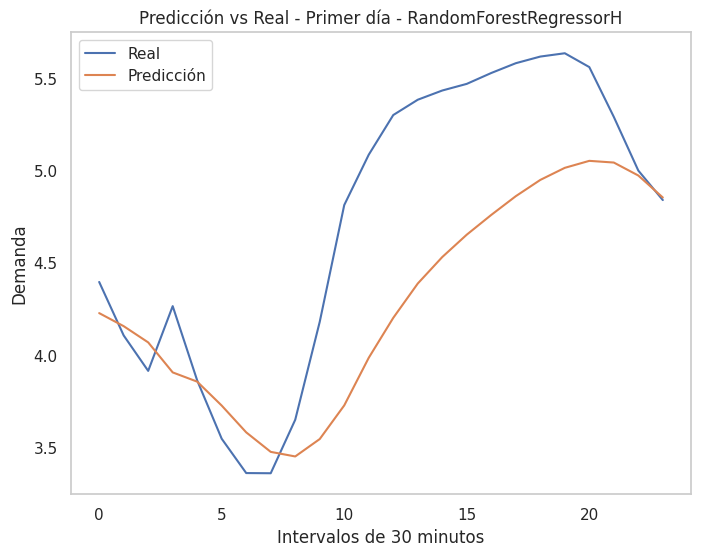

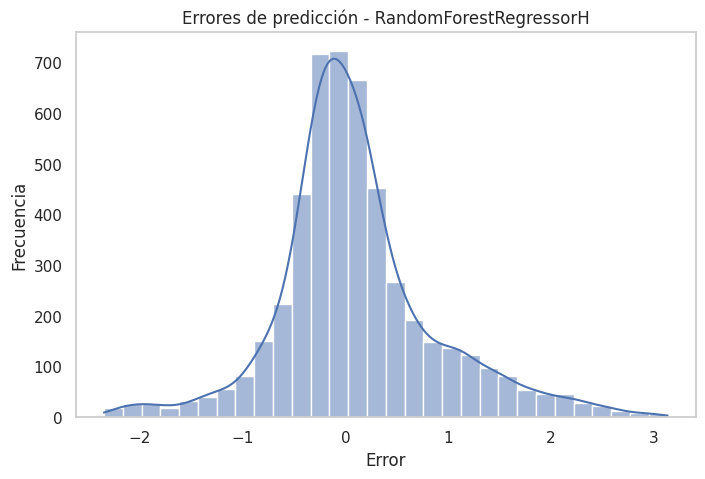


### Entrenando modelo: XGBRegressorH

MAE: 0.50, MSE: 0.57, RMSE: 0.75, R2: 0.73


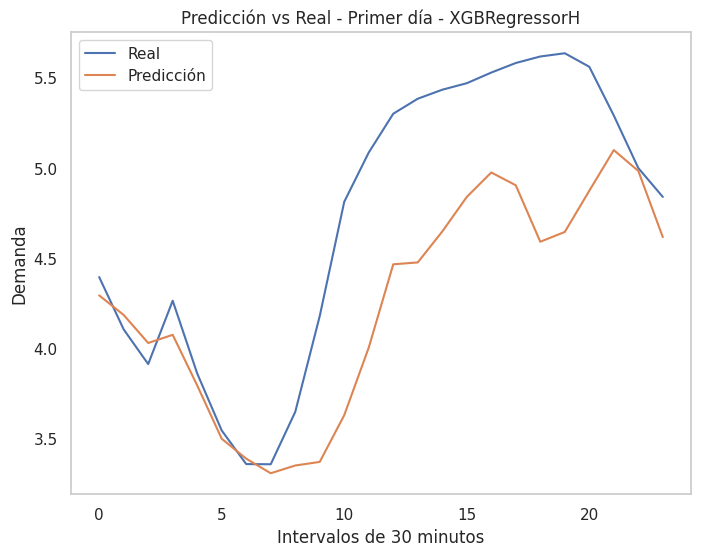

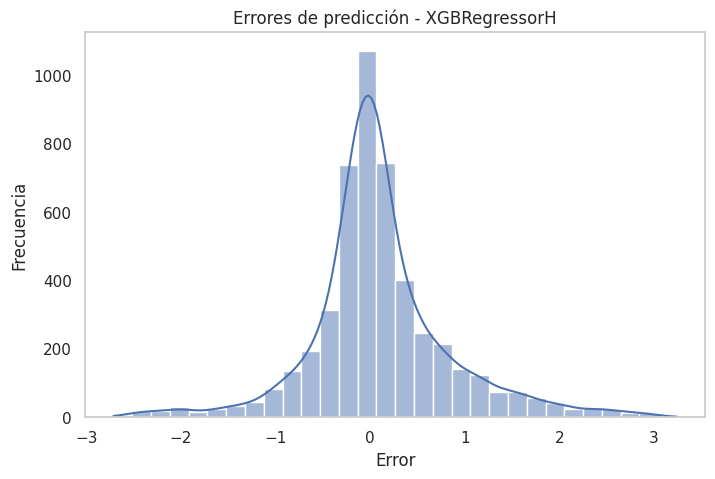

In [16]:
for name, model in models.items():
    print(f"\n### Entrenando modelo: {name}\n")

    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Métricas
        MAE = mean_absolute_error(y_test, y_pred)
        MSE = mean_squared_error(y_test, y_pred)
        RMSE = np.sqrt(MSE)
        R2 = r2_score(y_test, y_pred)

        results["Model"].append(name)
        results["MAE"].append(MAE)
        results["MSE"].append(MSE)
        results["RMSE"].append(RMSE)
        results["R2"].append(R2)

        print(f"MAE: {MAE:.2f}, MSE: {MSE:.2f}, RMSE: {RMSE:.2f}, R2: {R2:.2f}")

        # Guardar modelo
        dump(model, f"modelos-forecasting/{name}.joblib")

        # Visualización de predicción vs real
        plt.figure(figsize=(8,6))
        plt.plot(y_test[0], label="Real")
        plt.plot(y_pred[0], label="Predicción")
        plt.title(f"Predicción vs Real - Primer día - {name}")
        plt.xlabel("Intervalos de 30 minutos")
        plt.ylabel("Demanda")
        plt.legend()
        plt.grid()
        plt.show()

        # Histograma de errores
        residuals = y_test - y_pred
        plt.figure(figsize=(8,5))
        sns.histplot(residuals.flatten(), bins=30, kde=True)
        plt.title(f"Errores de predicción - {name}")
        plt.xlabel("Error")
        plt.ylabel("Frecuencia")
        plt.grid()
        plt.show()

    except Exception as e:
        print(f"Error en modelo {name}: {e}")

In [17]:
# Mostrar resumen de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)
results_df


,Model,MAE,MSE,RMSE,R2
3,XGBRegressorH,0.501596,0.566180,0.752449,0.733623
2,RandomForestRegressorH,0.548317,0.613339,0.783160,0.711029
0,LinearRegressionH,0.583369,0.628277,0.792639,0.704519
1,DecisionTreeRegressorH,0.669722,1.055181,1.027220,0.501237


# Resultados

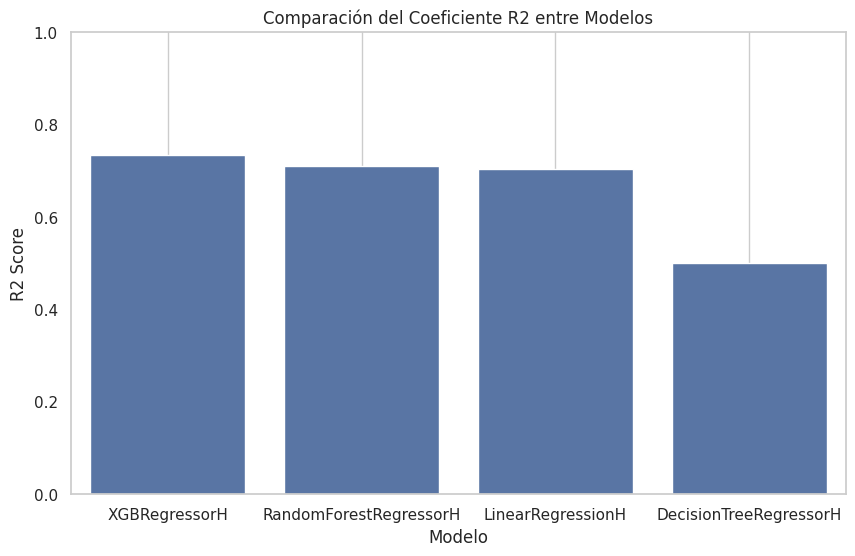

In [18]:
# Comparación de R2
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Comparación del Coeficiente R2 entre Modelos")
plt.xlabel("Modelo")
plt.ylabel("R2 Score")
plt.ylim(0,1)
plt.grid()
plt.show()

El mejor modelo fue XGBRegressorH